# Project 3: Customer Clustering and Segmentation

**Objective:** Segment customers using K-Means and DBSCAN.

This project includes:
- Customer-level feature engineering
- Feature scaling
- K-Means clustering
- Elbow method and Silhouette Score
- DBSCAN clustering
- PCA dimensionality reduction
- Cluster visualization
- Business interpretation

In [1]:
# Install and import libraries
!pip -q install ucimlrepo

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("Libraries loaded.")

Libraries loaded.


## 1. Download the Dataset

We use the UCI Online Retail dataset.

To avoid the previous `InvoiceNo` problem, this notebook first downloads the **original Excel dataset directly from the UCI repository** and reads it with pandas. It does not depend on the column structure returned by `ucimlrepo`.

In [2]:
# Download the UCI Online Retail dataset ZIP
!wget -q https://archive.ics.uci.edu/static/public/352/online+retail.zip

# Extract the Excel file
import zipfile
import pandas as pd

with zipfile.ZipFile("online+retail.zip", "r") as zip_ref:
    zip_ref.extractall()

# Load the dataset
data = pd.read_excel("Online Retail.xlsx")

print("Dataset shape:", data.shape)
print("Columns:", data.columns.tolist())
display(data.head())

Dataset shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Inspect and Clean the Data

In [3]:
print("Missing values:")
display(data.isnull().sum())

data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], errors="coerce")
data["InvoiceNo"] = data["InvoiceNo"].astype(str)

# Remove missing customer IDs and invalid transactions
data = data.dropna(subset=["CustomerID", "InvoiceDate"])
data = data[~data["InvoiceNo"].str.upper().str.startswith("C")]
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]

# Transaction value
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

print("Cleaned dataset shape:", data.shape)
display(data.head())

Missing values:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 3. Create Customer-Level Features

We aggregate transaction data into customer behavior features:

- **Recency:** days since the customer's latest purchase
- **Frequency:** number of unique invoices
- **Monetary:** total spending
- **AverageOrderValue:** average invoice value
- **AverageQuantity:** average quantity per transaction line

In [4]:
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

invoice_totals = (
    data.groupby(["CustomerID", "InvoiceNo"])["TotalPrice"]
    .sum()
    .reset_index(name="InvoiceValue")
)

customer_features = data.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AverageQuantity=("Quantity", "mean")
).reset_index()

customer_features["Recency"] = (
    reference_date - customer_features["LastPurchase"]
).dt.days

aov = invoice_totals.groupby("CustomerID")["InvoiceValue"].mean()
customer_features["AverageOrderValue"] = customer_features["CustomerID"].map(aov)

feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "AverageQuantity"
]

customer_features = customer_features[
    ["CustomerID"] + feature_cols
].dropna()

print("Customer-level dataset:", customer_features.shape)
display(customer_features.head())
display(customer_features[feature_cols].describe().round(2))

Customer-level dataset: (4338, 6)


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,AverageQuantity
0,12346.0,326,1,77183.60,77183.600000,74215.000000
1,12347.0,2,7,4310.00,615.714286,13.505495
2,12348.0,75,4,1797.24,449.310000,75.516129
3,12349.0,19,1,1757.55,1757.550000,8.643836
4,12350.0,310,1,334.40,334.400000,11.588235


,Recency,Frequency,Monetary,AverageOrderValue,AverageQuantity
count,4338.00,4338.00,4338.00,4338.00,4338.00
mean,92.54,4.27,2054.27,419.17,45.07
std,100.01,7.70,8989.23,1796.54,1203.44
min,1.00,1.00,3.75,3.45,1.00
25%,18.00,1.00,307.41,178.62,6.00
50%,51.00,2.00,674.48,293.90,10.00
75%,142.00,5.00,1661.74,430.11,14.67
max,374.00,209.00,280206.02,84236.25,74215.00


## 4. Feature Scaling

The features have different units and ranges, so StandardScaler is used before clustering.

In [5]:
X = customer_features[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (4338, 5)


## 5. K-Means: Select the Number of Clusters

We test several values of `k` using:
- Inertia / elbow method
- Silhouette Score

,k,inertia,silhouette_score
0,2,13797.0701,0.9759
1,3,9969.9633,0.8961
2,4,6392.8968,0.5770
3,5,5062.5066,0.5985
4,6,4143.6721,0.5787
5,7,3309.2207,0.5805
6,8,2654.9101,0.5812


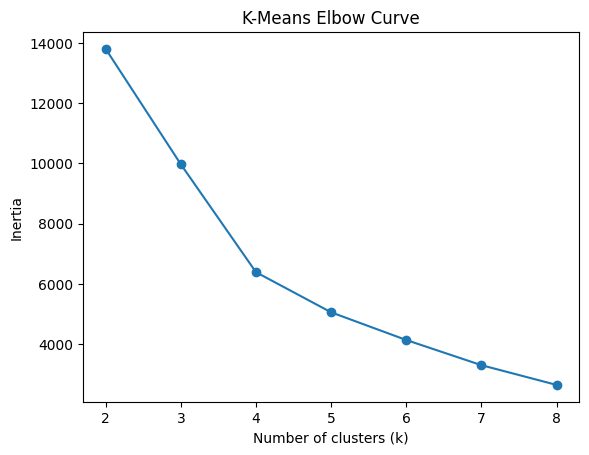

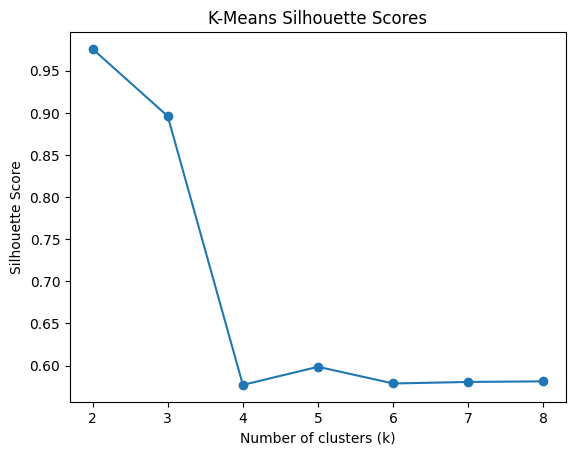

In [6]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(results.round(4))

fig, ax = plt.subplots()
ax.plot(list(k_values), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("K-Means Elbow Curve")
plt.show()

fig, ax = plt.subplots()
ax.plot(list(k_values), silhouette_scores, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("K-Means Silhouette Scores")
plt.show()

In [7]:
best_k = int(results.loc[results["silhouette_score"].idxmax(), "k"])

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_features["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(
    X_scaled,
    customer_features["KMeans_Cluster"]
)

print("Selected K:", best_k)
print("K-Means Silhouette Score:", round(kmeans_score, 4))

display(
    customer_features["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

Selected K: 2
K-Means Silhouette Score: 0.9759


,count
KMeans_Cluster,
0,4336
1,2


## 6. PCA Dimensionality Reduction

PCA reduces the five standardized features to two components for visualization. K-Means was trained using the original standardized five features.

PC1 variance: 0.4213
PC2 variance: 0.3027
Total variance explained: 0.7239


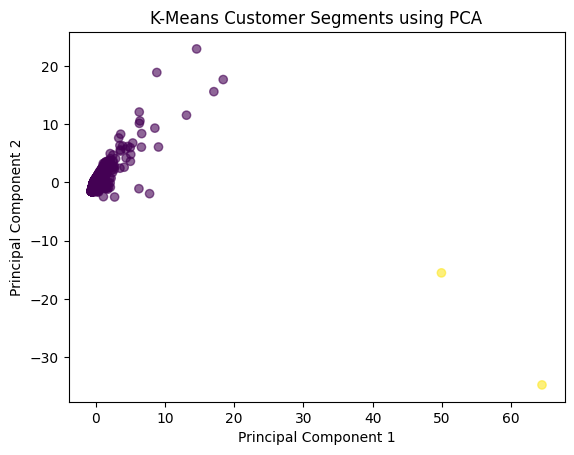

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variance = pca.explained_variance_ratio_.sum()

print("PC1 variance:", round(pca.explained_variance_ratio_[0], 4))
print("PC2 variance:", round(pca.explained_variance_ratio_[1], 4))
print("Total variance explained:", round(variance, 4))

fig, ax = plt.subplots()
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_features["KMeans_Cluster"],
    alpha=0.6
)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("K-Means Customer Segments using PCA")
plt.show()

## 7. K-Means Customer Profile

This table helps interpret the discovered segments in business terms.

In [9]:
cluster_profile = (
    customer_features
    .groupby("KMeans_Cluster")[feature_cols]
    .mean()
    .round(2)
)

cluster_profile.insert(
    0,
    "CustomerCount",
    customer_features["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .values
)

display(cluster_profile)

,CustomerCount,Recency,Frequency,Monetary,AverageOrderValue,AverageQuantity
KMeans_Cluster,,,,,,
0,4336,92.5,4.27,1998.56,382.13,21.74
1,2,163.5,1.50,122828.05,80709.92,50607.00


## 8. DBSCAN

DBSCAN is a density-based clustering method. It can discover clusters without specifying the number of clusters in advance and can identify noise points.

In [10]:
dbscan_results = []

for eps in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    model = DBSCAN(eps=eps, min_samples=8)
    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = int(np.sum(labels == -1))

    if n_clusters >= 2:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
    else:
        score = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": noise_points,
        "silhouette_score": score
    })

dbscan_results = pd.DataFrame(dbscan_results)

display(dbscan_results.round(4))

,eps,clusters,noise_points,silhouette_score
0,0.3,1,156,NaN
1,0.4,1,118,NaN
2,0.5,1,91,NaN
3,0.6,2,69,0.6944
4,0.7,1,63,NaN
5,0.8,2,54,0.4750


In [11]:
valid = dbscan_results.dropna(subset=["silhouette_score"])

if len(valid) > 0:
    best_row = valid.loc[valid["silhouette_score"].idxmax()]
    best_eps = float(best_row["eps"])
else:
    best_eps = 0.50

dbscan = DBSCAN(eps=best_eps, min_samples=8)
customer_features["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

db_labels = customer_features["DBSCAN_Cluster"].values
db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise = int(np.sum(db_labels == -1))

if db_clusters >= 2:
    mask = db_labels != -1
    db_score = silhouette_score(X_scaled[mask], db_labels[mask])
else:
    db_score = np.nan

print("Selected DBSCAN eps:", best_eps)
print("DBSCAN clusters:", db_clusters)
print("DBSCAN noise points:", db_noise)
print(
    "DBSCAN Silhouette Score:",
    "N/A" if np.isnan(db_score) else round(db_score, 4)
)

Selected DBSCAN eps: 0.6
DBSCAN clusters: 2
DBSCAN noise points: 69
DBSCAN Silhouette Score: 0.6944


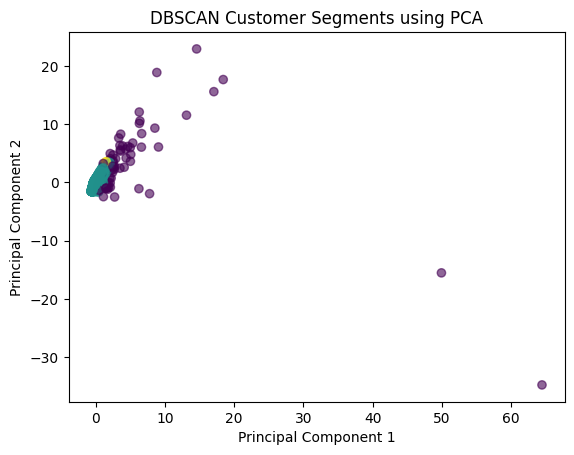

In [12]:
fig, ax = plt.subplots()
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_features["DBSCAN_Cluster"],
    alpha=0.6
)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("DBSCAN Customer Segments using PCA")
plt.show()

## 9. Compare K-Means and DBSCAN

The comparison considers cluster count, silhouette score, and DBSCAN noise points. The final business interpretation should use the cluster profiles rather than assuming labels in advance.

In [13]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN"],
    "Clusters": [best_k, db_clusters],
    "SilhouetteScore": [
        kmeans_score,
        db_score if not np.isnan(db_score) else np.nan
    ],
    "NoisePoints": [0, db_noise]
})

display(comparison.round(4))

,Method,Clusters,SilhouetteScore,NoisePoints
0,K-Means,2,0.9759,0
1,DBSCAN,2,0.6944,69


## 10. Business Interpretation

Potential interpretations include:

- **High-value/frequent customers:** loyalty programs and premium offers.
- **Recent but lower-frequency customers:** encourage repeat purchases.
- **Low-spend/inactive customers:** re-engagement campaigns.
- **DBSCAN noise:** unusual customer behavior that may need investigation.

The exact names should be assigned after examining the cluster profile above.

In [14]:
# Rank clusters on key business characteristics
profile_for_review = cluster_profile.copy()

display(profile_for_review)

,CustomerCount,Recency,Frequency,Monetary,AverageOrderValue,AverageQuantity
KMeans_Cluster,,,,,,
0,4336,92.5,4.27,1998.56,382.13,21.74
1,2,163.5,1.50,122828.05,80709.92,50607.00


## 11. Final Conclusion

This project applies two unsupervised learning techniques to customer purchasing behavior.

K-Means is evaluated using inertia and silhouette score. DBSCAN is evaluated across multiple density settings and can identify noise points. PCA provides a two-dimensional representation for visualization.

The resulting customer profiles can support targeted marketing and customer-retention decisions.

In [15]:
print("PROJECT 3 COMPLETE")
print("=" * 50)
print(f"Customers analyzed: {len(customer_features):,}")
print(f"Selected K-Means clusters: {best_k}")
print(f"K-Means silhouette score: {kmeans_score:.4f}")
print(f"Selected DBSCAN eps: {best_eps}")
print(f"DBSCAN clusters: {db_clusters}")
print(f"DBSCAN noise points: {db_noise}")
print(f"PCA variance explained: {variance:.4f}")

PROJECT 3 COMPLETE
Customers analyzed: 4,338
Selected K-Means clusters: 2
K-Means silhouette score: 0.9759
Selected DBSCAN eps: 0.6
DBSCAN clusters: 2
DBSCAN noise points: 69
PCA variance explained: 0.7239
